# Gaussian gate compilation

Compile a rotation and squeeze, then inspect the exact affine channel.

Compilation expresses the target symplectic map through homodyne teleportation gadgets. The channel analyzer separates its ideal matrix from finite-resource noise.

Linear map: [[ 0.782163 -0.241951]
 [ 0.360949  1.166851]]
Added noise: [[0.73451  0.191785]
 [0.191785 1.33368 ]]
Generated measurements: [(2, 6, 10, 14), (18, 22, 26, 30, 34)]


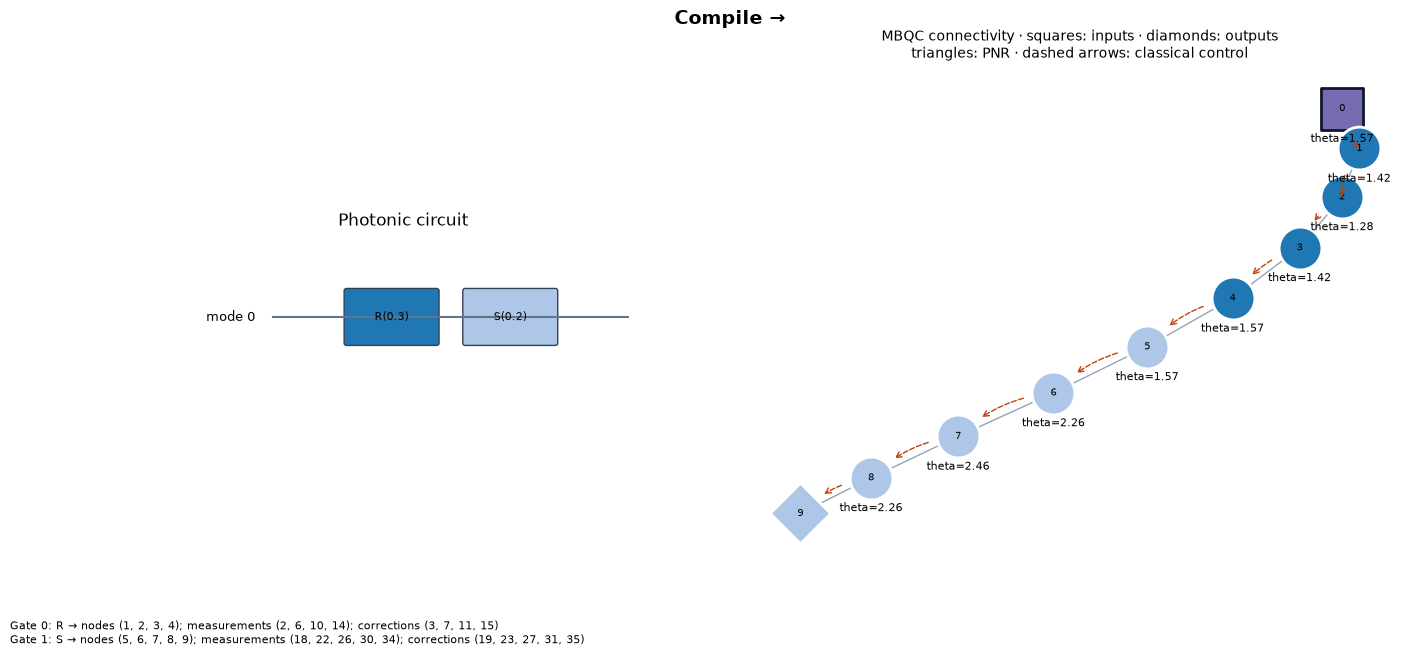

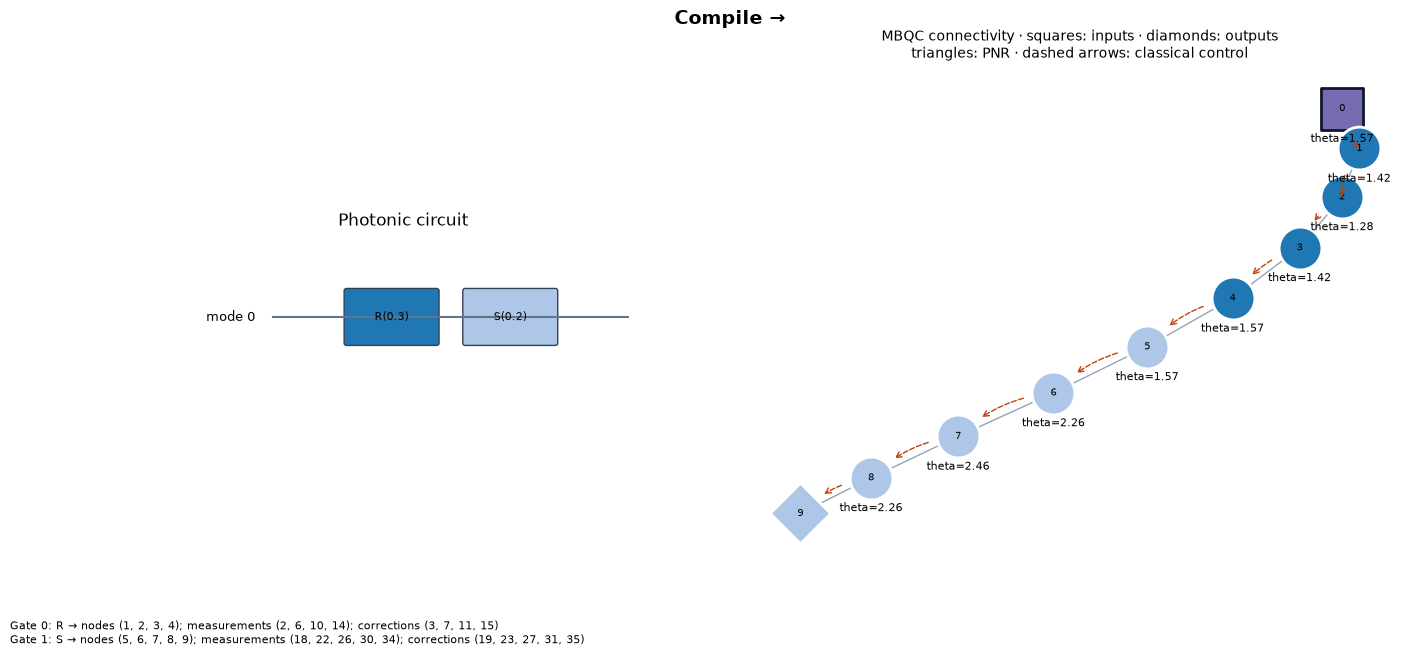

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import photographiq as pg
circuit = pg.Circuit(1).rotate(0,0.3).squeeze(0,0.2)
pattern, trace = circuit.compile(squeezing=0.8, return_trace=True)
channel = pg.gaussian_channel(pattern)
print("Linear map:", np.round(channel.matrix, 6))
print("Added noise:", np.round(channel.noise, 6))
print("Generated measurements:", [step.measurements for step in trace.steps])
assert len(trace.steps) == 2
pg.visualize_compilation(circuit, pattern, trace=trace)

## Interpretation

The output linear map is the composed gate action. Noise is separately nonzero, and trace indices show the measurement cost of each gate.

## Exercise

Reverse the gate order and predict which matrix changes. Compare resource counts for identity and a generic rotation.